In [ ]:

# Install the required libraries for CNN and ViT
!pip install -q torch torchvision transformers scikit-learn pillow


In [ ]:
# Import libraries for model training, image processing and evaluation
import tensorflow as tf
from tensorflow.keras import layers, models
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
from transformers import ViTImageProcessor, TFViTForImageClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("TensorFlow:", tf.__version__)
print("PyTorch:", torch.__version__)
print("Device:", device)


TensorFlow: 2.20.0
PyTorch: 2.11.0+cu130
Device: cuda


In [ ]:
# Load the complete CIFAR-10 dataset and normalize pixel values
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (50000, 32, 32, 3)
Testing data: (10000, 32, 32, 3)


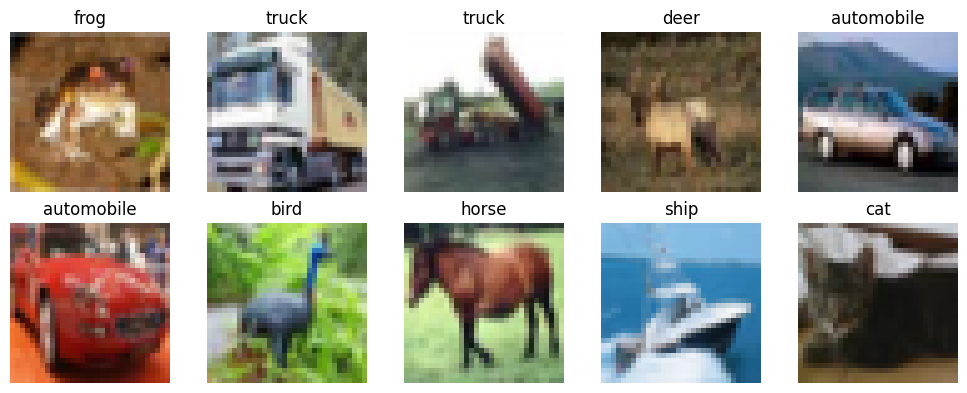

In [ ]:
# Display sample images from the training dataset
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i][0])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Create a CNN model for CIFAR-10 image classification
cnn = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the CNN on the full training dataset for five epochs
cnn_history = cnn.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.4604 - loss: 1.4995 - val_accuracy: 0.5698 - val_loss: 1.2103
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5987 - loss: 1.1467 - val_accuracy: 0.6078 - val_loss: 1.1193
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6472 - loss: 1.0106 - val_accuracy: 0.6518 - val_loss: 0.9919
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6796 - loss: 0.9204 - val_accuracy: 0.6806 - val_loss: 0.9323
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7033 - loss: 0.8498 - val_accuracy: 0.6810 - val_loss: 0.9307


In [ ]:
# Evaluate the CNN on all test images and generate predictions
cnn_loss, cnn_accuracy = cnn.evaluate(x_test, y_test, verbose=0)
cnn_pred = np.argmax(cnn.predict(x_test), axis=1)

print("CNN Accuracy:", accuracy_score(y_test.flatten(), cnn_pred))
print(classification_report(y_test.flatten(), cnn_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
CNN Accuracy: 0.6722
              precision    recall  f1-score   support

    airplane       0.77      0.66      0.71      1000
  automobile       0.70      0.88      0.78      1000
        bird       0.54      0.55      0.55      1000
         cat       0.61      0.37      0.46      1000
        deer       0.64      0.59      0.61      1000
         dog       0.52      0.67      0.59      1000
        frog       0.68      0.81      0.74      1000
       horse       0.72      0.77      0.74      1000
        ship       0.87      0.67      0.76      1000
       truck       0.73      0.76      0.74      1000

    accuracy                           0.67     10000
   macro avg       0.68      0.67      0.67     10000
weighted avg       0.68      0.67      0.67     10000



In [ ]:
# Load the pre-trained Vision Transformer and its image processor
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')

vit = TFViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=10,
    ignore_mismatched_sizes=True
)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFViTForImageClassification: ['classifier.weight', 'classifier.bias']
- This IS expected if you are initializing TFViTForImageClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTForImageClassification from a PyTorch m

In [ ]:
# Preprocess small batches of images to avoid running out of RAM
import math

batch_size = 4

def batch_generator(images, labels, batch_size=4, shuffle=False):
    indices = np.arange(len(images))
    if shuffle:
        np.random.shuffle(indices)

    for start in range(0, len(images), batch_size):
        idx = indices[start:start + batch_size]
        batch_images = (images[idx] * 255).astype(np.uint8)

        pixel_values = processor(
            images=list(batch_images),
            return_tensors="np"
        )["pixel_values"]

        yield pixel_values.astype(np.float32), labels[idx].astype(np.int32).reshape(-1)

train_ds = tf.data.Dataset.from_generator(
    lambda: batch_generator(x_train[:5000], y_train[:5000], batch_size, shuffle=True),
    output_signature=(
        tf.TensorSpec(shape=(None, 3, 224, 224), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.int32)
    )
)

test_ds = tf.data.Dataset.from_generator(
    lambda: batch_generator(x_test[:1000], y_test[:1000], batch_size),
    output_signature=(
        tf.TensorSpec(shape=(None, 3, 224, 224), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.int32)
    )
)

print("ViT training images: 5000")
print("ViT testing images: 1000")

ViT training images: 5000
ViT testing images: 1000


In [ ]:
# Fine-tune ViT using the same Keras version as the Hugging Face model
import tf_keras

vit.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=5e-5),
    loss=tf_keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

vit.fit(
    train_ds,
    epochs=2,
    steps_per_epoch=math.ceil(5000 / batch_size)
)

# Generate predictions for the test subset in batches
all_logits = []

for pixel_values, labels in test_ds:
    outputs = vit(pixel_values=pixel_values, training=False)
    all_logits.extend(outputs.logits.numpy())

vit_pred = np.argmax(np.array(all_logits), axis=1)
test_lab = y_test[:1000].flatten()

print("ViT Accuracy:", accuracy_score(test_lab, vit_pred))
print(classification_report(test_lab, vit_pred, target_names=class_names))

Epoch 1/2
1250/1250 [==============================] - 311s 212ms/step - loss: 0.2750 - accuracy: 0.9286
Epoch 2/2


1250/1250 [==============================] - 1s 737us/step - loss: 0.0000e+00 - accuracy: 0.0000e+00
ViT Accuracy: 0.955
              precision    recall  f1-score   support

    airplane       0.99      0.99      0.99       103
  automobile       0.98      0.97      0.97        89
        bird       1.00      0.98      0.99       100
         cat       0.95      0.81      0.87       103
        deer       1.00      0.90      0.95        90
         dog       0.80      0.94      0.87        86
        frog       0.98      0.99      0.99       112
       horse       0.90      1.00      0.95       102
        ship       0.99      0.99      0.99       106
       truck       0.96      0.97      0.97       109

    accuracy                           0.95      1000
   macro avg       0.96      0.95      0.95      1000
weighted avg       0.96      0.95      0.96      1000



  Model  Accuracy  Precision  Recall  F1-Score
0   CNN     0.682     0.6897   0.682    0.6785
1   ViT     0.955     0.9583   0.955    0.9550


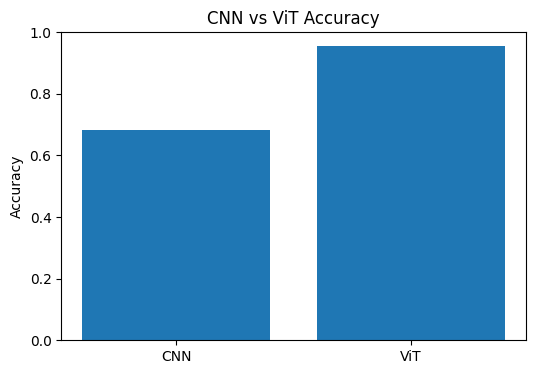

In [ ]:
# Compare CNN and ViT performance using the same test images
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# Get CNN predictions for the same 1,000 images used by ViT
cnn_pred_subset = cnn_pred[:1000]
cnn_true = y_test[:1000].flatten()
vit_true = test_lab

results = pd.DataFrame({
    "Model": ["CNN", "ViT"],
    "Accuracy": [
        accuracy_score(cnn_true, cnn_pred_subset),
        accuracy_score(vit_true, vit_pred)
    ],
    "Precision": [
        precision_score(cnn_true, cnn_pred_subset, average="weighted", zero_division=0),
        precision_score(vit_true, vit_pred, average="weighted", zero_division=0)
    ],
    "Recall": [
        recall_score(cnn_true, cnn_pred_subset, average="weighted", zero_division=0),
        recall_score(vit_true, vit_pred, average="weighted", zero_division=0)
    ],
    "F1-Score": [
        f1_score(cnn_true, cnn_pred_subset, average="weighted", zero_division=0),
        f1_score(vit_true, vit_pred, average="weighted", zero_division=0)
    ]
})

print(results.round(4))

# Visualize the accuracy comparison
plt.figure(figsize=(6, 4))
plt.bar(results["Model"], results["Accuracy"])
plt.title("CNN vs ViT Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()